---
---
# 1. Dataset Selection and Preparation
---
**I. Purpose of each line of code:**
* `import kagglehub ...`: Imports necessary libraries for data retrieval (`kagglehub`), data manipulation (`pandas`, `numpy`), and visualization (`seaborn`, `matplotlib`).
* `from sklearn...`: Imports machine learning modules for splitting data, building regression models, and calculating error metrics.
* `kagglehub.dataset_download(...)`: Downloads the specific housing dataset ("linkanjarad/housing-prices-dataset-philippines") directly to the Colab environment.
* `os.listdir(path)`: Scans the downloaded folder to find the exact filename of the CSV.
* `pd.read_csv(...)`: Loads the CSV file into a Pandas DataFrame named `df_raw`. This creates our initial "raw" dataset.

**II. Input:**
* **Source Data:** The "Housing Prices Dataset - Philippines" hosted on Kaggle.
* **Libraries:** `pandas`, `numpy`, `seaborn`, `matplotlib`, `sklearn`, `os`.

**III. Output:**
* **Variable `df_raw`:** A DataFrame containing the uncleaned housing data.
* **Console Output:** Prints a success message and the first 3 rows (`head(3)`) to confirm the data loaded correctly.

---
---

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Import Sklearn (Machine Learning) Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Download Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("linkanjarad/housing-prices-dataset-philippines")

# 2. Find and Load CSV automatically
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    # Load into 'df_raw' (This is your DIRTY starting point)
    df_raw = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"\n✅ SUCCESS: Data loaded into 'df_raw'. Shape: {df_raw.shape}")
    print(df_raw.head(3))
else:
    print("❌ ERROR: No CSV file found.")

100%|██████████| 218k/218k [00:00<00:00, 565kB/s]

Extracting files...

✅ SUCCESS: Data loaded into 'df_raw'. Shape: (2999, 12)
   Unnamed: 0                                              Title  Bathrooms  \
0           0  Natalie 3BR Single Detached House for Sale in ...        3.0   
1           1  Townhouse with 2 Bedrooms for Sale at Hana Sou...        2.0   
2           2  RFO 1BR 2-Storey Rowhouse for Sale at Marytown...        1.0   

   Bedrooms  Car Spaces  Floor area (m²)  Land Size (m²)    Subdivision name  \
0       3.0         1.0            123.8           140.0  West Beverly Hills   
1       2.0         NaN             38.0            36.0          Hana South   
2       1.0         NaN             46.6            67.0      Marytown Place   

  Block and Lot/Unit Number  Build (Year)  Rooms (total)      Price  
0                       NaN           NaN            NaN  5493461.0  
1                Lyca model           NaN            NaN  1918427.0  
2   Blk1 Lot23 (ROSE-INNER)        2019.0            NaN  1700404.0  


---
---
# 2. Initial Data Inspection (Audit)
---
**I. Purpose of each line of code:**
* `df_raw.isnull().sum()`: Scans every column to count how many "NaN" (missing) values exist.
* `df_raw.duplicated().sum()`: Checks for identical rows that might distort the model.
* `df_raw['Price'].isnull().sum()`: Specifically checks the Target variable ('Price'). If this is missing, the row is useless for training.
* `sns.heatmap(...)`: Generates a visual map where yellow lines represent missing data, helping us instantly spot "dirty" columns.

**II. Input:**
* **Data:** `df_raw` (The raw dataframe loaded in Step 1).

**III. Output:**
* **Text Report:** Lists the count of missing values per column and total duplicates.
* **Visual Plot:** A Heatmap displaying the distribution of missing data (Yellow = Missing, Purple = Present).
---
---

--- INITIAL DATA HEALTH CHECK (df_raw) ---

[1] Missing Values:
Title                          75
Bathrooms                     761
Bedrooms                      724
Car Spaces                   1788
Floor area (m²)                82
Land Size (m²)                155
Subdivision name             1112
Block and Lot/Unit Number    1824
Build (Year)                 2488
Rooms (total)                2491
Price                          75
dtype: int64

[2] Duplicates: 0

[3] Rows with NO Price: 75
    -> CRITICAL: These rows must be dropped.


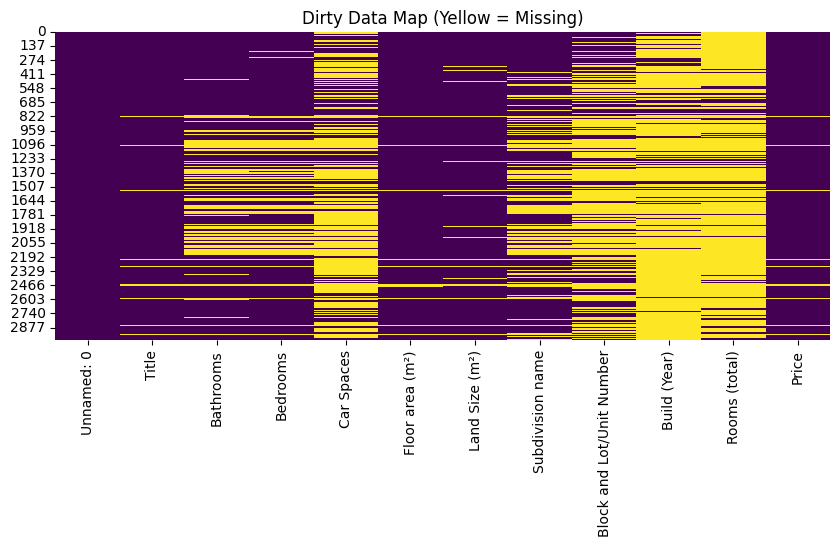

In [2]:
print("--- INITIAL DATA HEALTH CHECK (df_raw) ---")

# 1. Check Missing Values
print("\n[1] Missing Values:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

# 2. Check Duplicates
print(f"\n[2] Duplicates: {df_raw.duplicated().sum()}")

# 3. Target Check (Price)
missing_price = df_raw['Price'].isnull().sum()
print(f"\n[3] Rows with NO Price: {missing_price}")
if missing_price > 0:
    print("    -> CRITICAL: These rows must be dropped.")

# 4. Visual Map
plt.figure(figsize=(10, 4))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis')
plt.title("Dirty Data Map (Yellow = Missing)")
plt.show()

---
---
# 3. Data Cleaning and Preprocessing
---
**I. Purpose of each line of code:**
* `df_clean = df_raw.copy()`: Creates a backup so we don't accidentally destroy the original data.
* `dropna(subset=['Price'])`: Removes rows where the target 'Price' is missing, as these cannot be used for regression.
* `drop(columns=...)`: Removes columns like 'Rooms' and 'Build Year' which had >80% missing data in the assessment.
* `fillna(0)`: Fills missing 'Car Spaces' with 0, assuming NaN means "no garage".
* `fillna(df_clean[col].median())`: Fills missing physical stats (Bedrooms, Floor Area) with the median value to handle outliers robustly.
* `rename(columns=...)`: Renames columns to remove spaces (e.g., 'Floor area (m²)' -> 'Floor_Area') for easier coding.

**II. Input:**
* **Data:** `df_raw` (The dirty dataset).

**III. Output:**
* **Variable `df_clean`:** A new, processed DataFrame with no missing values, ready for analysis.
* **Console Output:** Prints the new shape of the dataset (rows, columns).
---
---

In [3]:
# Create a copy so we don't mess up the original
df_clean = df_raw.copy()

# 1. Drop Rows with Missing Price (Can't train without target)
df_clean = df_clean.dropna(subset=['Price'])

# 2. Drop Columns with too much missing data or useless text
# 'Title' and 'Subdivision' are text that is too messy for simple regression
cols_to_drop = ['Rooms (total)', 'Build (Year)', 'Block and Lot/Unit Number',
                'Unnamed: 0', 'Title', 'Subdivision name']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 3. Fill Missing Values
# Car Spaces: NaN -> 0
if 'Car Spaces' in df_clean.columns:
    df_clean['Car Spaces'] = df_clean['Car Spaces'].fillna(0)

# Physical Specs: NaN -> Median (to avoid outliers)
for col in ['Bedrooms', 'Bathrooms', 'Floor area (m²)', 'Land Size (m²)']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 4. Clean Column Names (Remove spaces/special chars)
df_clean = df_clean.rename(columns={
    'Floor area (m²)': 'Floor_Area',
    'Land Size (m²)': 'Land_Size',
    'Car Spaces': 'Car_Spaces'
})

print(f"✅ CLEANING DONE. Created 'df_clean'. New Shape: {df_clean.shape}")

✅ CLEANING DONE. Created 'df_clean'. New Shape: (2924, 6)


---
---
# 4. Post-Cleaning Verification
---
**I. Purpose of each line of code:**
* `df_clean.isnull().sum().sum()`: Calculates the total number of missing cells remaining in the cleaned dataset.
* `if missing == 0`: A logic check to confirm the cleaning was successful.
* `sns.heatmap(...)`: Plots the heatmap again. This time, it should be solid purple, proving all "yellow" gaps are gone.

**II. Input:**
* **Data:** `df_clean` (The cleaned dataset from Step 3).

**III. Output:**
* **Validation Message:** "✅ STATUS: READY FOR MODELING" if successful.
* **Visual Plot:** A solid purple heatmap confirming zero missing values.
---
---

--- POST-CLEANING CHECK (df_clean) ---
Remaining Missing Values: 0
✅ STATUS: READY FOR MODELING


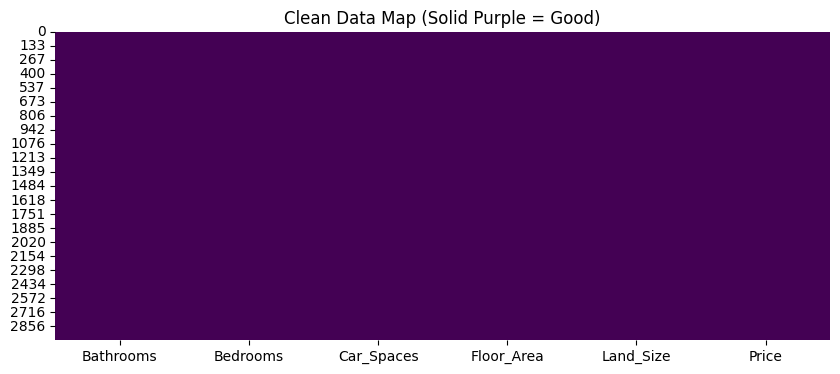

In [4]:
print("--- POST-CLEANING CHECK (df_clean) ---")

# 1. Final Missing Check
missing = df_clean.isnull().sum().sum()
print(f"Remaining Missing Values: {missing}")

# 2. Visual Proof
if missing == 0:
    print("✅ STATUS: READY FOR MODELING")
    plt.figure(figsize=(10, 4))
    sns.heatmap(df_clean.isnull(), cbar=False, cmap='viridis')
    plt.title("Clean Data Map (Solid Purple = Good)")
    plt.show()
else:
    print("❌ WARNING: Data is still dirty. Check Cell 3.")

---
---
# 5. Attribute Selection (Correlation Analysis)
---
**I. Purpose of each line of code:**
* `df_clean.corr()`: Calculates the Pearson correlation coefficient between all numerical variables (range -1 to 1).
* `sns.heatmap(..., annot=True)`: Visualizes the correlation matrix. Darker red indicates stronger positive correlation.
* `sort_values(ascending=False)`: Sorts the variables to show which features have the strongest relationship with 'Price'.

**II. Input:**
* **Data:** `df_clean` (numerical columns only).

**III. Output:**
* **Correlation Matrix:** A table/heatmap showing relationships.
* **Top Predictors:** Identifying that 'Floor_Area', 'Bedrooms', and 'Bathrooms' are highly correlated with Price.
---
---

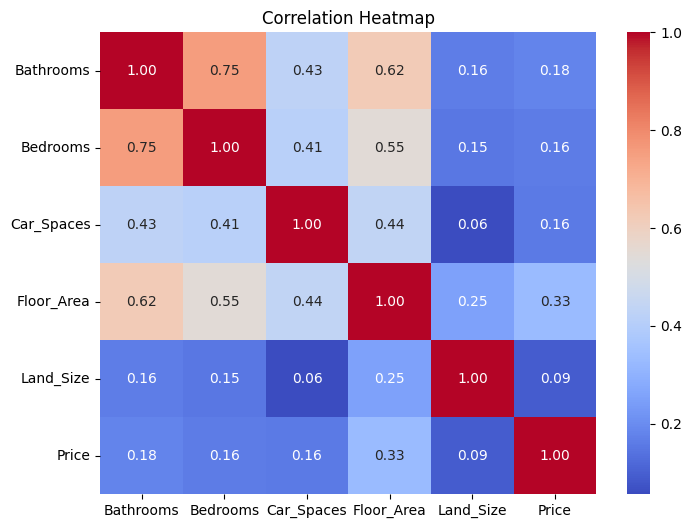

Correlation with Price:
Price         1.000000
Floor_Area    0.325070
Bathrooms     0.179475
Bedrooms      0.162094
Car_Spaces    0.156331
Land_Size     0.092436
Name: Price, dtype: float64


In [5]:
# Calculate correlation matrix
corr_matrix = df_clean.corr()

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Print Top Predictors for Price
print("Correlation with Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

---
---
# 6. Data Splitting
---
**I. Purpose of each line of code:**
* `features = [...]`: Selects the independent variables (X) identified in the correlation step (Floor_Area, Bedrooms, etc.).
* `target = 'Price'`: Selects the dependent variable (y) we want to predict.
* `train_test_split(...)`: Randomly splits the data into two sets:
    * **Training Set (80%):** Used to teach the model.
    * **Testing Set (20%):** Hidden from the model to evaluate performance later.
* `random_state=42`: Ensures the split is reproducible (same random rows every time).

**II. Input:**
* **Data:** `df_clean`.
* **Parameters:** `test_size=0.2` (20% split).

**III. Output:**
* **Variables:** `X_train`, `X_test`, `y_train`, `y_test`.
* **Console Output:** Prints the number of rows in the Training vs. Testing sets.
---
---

In [6]:
# 1. Define Features (X) and Target (y)
# We use the top correlated features found in Cell 5
features = ['Floor_Area', 'Bathrooms', 'Bedrooms', 'Land_Size', 'Car_Spaces']
target = 'Price'

X = df_clean[features]
y = df_clean[target]

# 2. Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} rows")
print(f"Testing Data : {X_test.shape[0]} rows")

Training Data: 2339 rows
Testing Data : 585 rows


---
---
# 7. Model Building: Simple Linear Regression
---
**I. Purpose of each line of code:**
* `feature_col = 'Floor_Area'`: Selects the single variable with the highest correlation to Price.
* `model = LinearRegression()`: Initializes the linear regression algorithm.
* `model.fit(...)`: Trains the model to find the best-fit line ($y = mx + b$) between Floor Area and Price using only the training data.
* `model.predict(...)`: Uses the trained line to guess prices for the test set.
* `plt.scatter` & `plt.plot`: Visualizes the results by plotting the actual data points (blue dots) against the model's regression line (red line).

**II. Input:**
* **Data:** `X` (Floor_Area values from `df_clean`), `y` (Price values from `df_clean`).
* **Note:** This cell creates its own train/test split from `df_clean`.

**III. Output:**
* **Trained Model:** An SLR model capable of predicting Price from Floor Area.
* **Visualization:** A Scatter Plot showing the regression line.
* **Coefficients:** The slope (m) and intercept (b) of the line.
---
---

Coefficient (Slope): 177575.69
Intercept: -10484151.57
------------------------------
Mean Squared Error (MSE): 2211189356209870.50
R-squared (R2) Score: 0.35


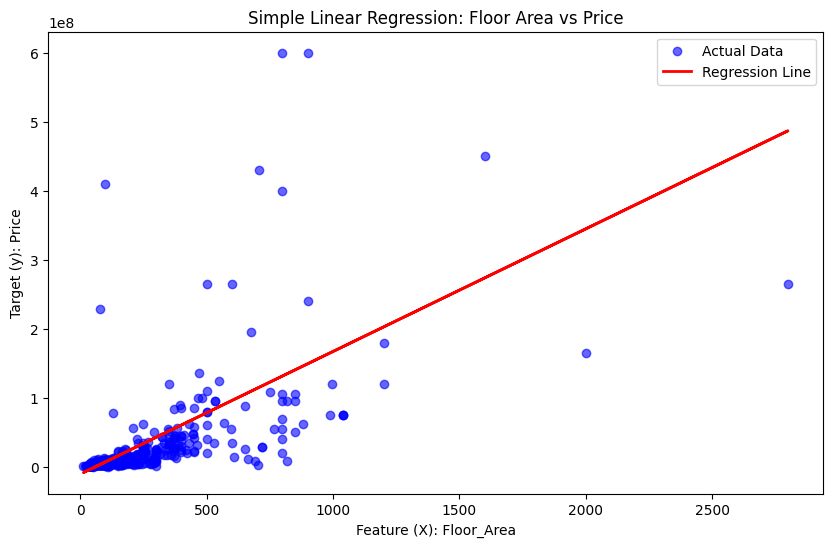

In [7]:
# 1. Setup Data (Matches "Generate synthetic data" step)
# We use the real data instead of np.random
feature_col = 'Floor_Area'
target_col = 'Price'

X = df_clean[[feature_col]].values  # Reshape to 2D array like in the image
y = df_clean[target_col].values

# 2. Split data (Matches "Split data into training and testing sets")
# Using the same random_state=42 as your image
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Model (Matches "Initialize and train...")
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Make Predictions (Matches "Make predictions...")
y_pred = model.predict(X_test)

# 5. Output Metrics (Matches "Output Evaluation Metrics" print style)
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print("-" * 30)
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.2f}")
print(f"R-squared (R2) Score: {r2_score(y_test, y_pred):.2f}")

# 6. Plotting (Matches "Plotting the results")
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Data', alpha=0.6)
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel(f'Feature (X): {feature_col}')
plt.ylabel(f'Target (y): {target_col}')
plt.title('Simple Linear Regression: Floor Area vs Price')
plt.legend()
plt.show()

---
---
# 8. Interactive Prediction Loop
---
**i. Purpose of each line of code:**
* `while True`: Starts an infinite loop so the user can make multiple predictions without restarting the cell.
* `input(...)`: Pauses the program to ask the user to type a Floor Area (sqm).
* `if ... 'exit'`: Provides a way to break (stop) the loop.
* `float(user_input)`: Converts the text input into a number the model can understand.
* `model.predict(...)`: Uses the SLR model from Step 7 to predict the price for the user's input.
* `try...except`: Prevents the program from crashing if the user types text instead of a number.

**ii. Input:**
* **User Input:** A numerical value for Floor Area (e.g., "50").

**iii. Output:**
* **Prediction:** Prints the estimated Price (e.g., "₱3,500,000.00") based on the input.
---
---

In [8]:
print("\n" + "="*30)
print("LINEAR REGRESSION PREDICTOR")
print("="*30)
print(f"The model is trained on {feature_col}.")
print(f"Enter a value for {feature_col} (sqm) to see the predicted {target_col}.")
print("Type 'exit' to close the program.")

while True:
    user_input = input(f"\nEnter value for {feature_col}: ")

    if user_input.lower() == 'exit':
        print("Exiting... Goodbye!")
        break

    try:
        # Matches "Convert input to float and reshape"
        x_new = float(user_input)
        x_val = np.array([[x_new]])

        # Matches "Predict"
        y_val = model.predict(x_val)

        print(f">>> Predicted Price: ₱{y_val[0]:,.2f}")

    except ValueError:
        print("Invalid input! Please enter a numerical value.")


LINEAR REGRESSION PREDICTOR
The model is trained on Floor_Area.
Enter a value for Floor_Area (sqm) to see the predicted Price.
Type 'exit' to close the program.

Enter value for Floor_Area: 50
>>> Predicted Price: ₱-1,605,367.23

Enter value for Floor_Area: 100
>>> Predicted Price: ₱7,273,417.10

Enter value for Floor_Area: 300
>>> Predicted Price: ₱42,788,554.45

Enter value for Floor_Area: exit
Exiting... Goodbye!


---
---
# 9. Multiple Linear Regression & Performance Evaluation
---
**i. Purpose of each line of code:**
* `feature_cols_multi = [...]`: Selects multiple features (Floor Area, Bedrooms, Bathrooms, etc.) for the MLR model.
* `mlr_model.fit(...)`: Trains a new model using ALL selected features simultaneously.
* `mean_absolute_error (MAE)`: Calculates the average error in Pesos.
* `mean_squared_error (RMSE)`: penalizes larger errors more heavily.
* `r2_score`: Measures how well the model explains the variance (0.0 to 1.0).
* `residuals = y_test_m - y_pred_multi`: Calculates the exact error for every prediction.
* `plt.scatter(...)`: Plots the Residuals to check for patterns (Homoscedasticity).

**ii. Input:**
* **Data:** `X_train_m` (5 features), `y_train_m`.
* **Predictions:** `y_pred_simple` vs `y_pred_multi`.

**iii. Output:**
* **Comparison Report:** Prints MAE, RMSE, and R2 for both Simple and Multiple regression.
* **Residual Plot:** A scatter plot visualizing the model's errors.
---
---

   MODEL PERFORMANCE COMPARISON   

--- SIMPLE Regression (Floor Area Only) ---
Mean Absolute Error (MAE): ₱17,870,573.30
Root Mean Squared Error (RMSE): ₱47,023,285.26
R-squared (R2) Score: 0.3459

--- MULTIPLE Regression (5 Features) ---
Mean Absolute Error (MAE): ₱17,640,543.21
Root Mean Squared Error (RMSE): ₱47,332,640.20
R-squared (R2) Score: 0.3372


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


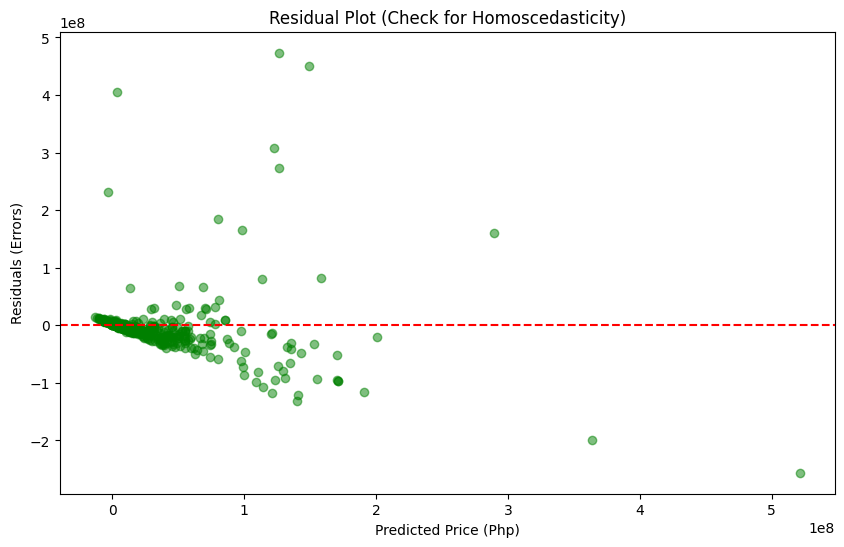


INTERPRETATION:
MLR Coefficients: [ 1.87285557e+05  1.09445525e+06 -5.46465762e+06  7.20908698e+02
  2.22496044e+06]
Features: ['Floor_Area', 'Bedrooms', 'Bathrooms', 'Land_Size', 'Car_Spaces']
If R2 is higher for Multiple Regression, adding features improved the model.


In [9]:
# 1. Prepare Data for Multiple Regression (Using ALL numeric features)
# We use the same 'df_clean' but select multiple columns this time.
feature_cols_multi = ['Floor_Area', 'Bedrooms', 'Bathrooms', 'Land_Size', 'Car_Spaces']
target_col = 'Price'

# Create X and y for Multiple Regression
X_multi = df_clean[feature_cols_multi]
y_multi = df_clean[target_col]

# Split (80% Train, 20% Test) - strictly following the same random_state=42 for fairness
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# 2. Train Multiple Linear Regression (MLR)
mlr_model = LinearRegression()
mlr_model.fit(X_train_m, y_train_m)
y_pred_multi = mlr_model.predict(X_test_m)

# 3. Retrieve Simple Model Predictions (Re-running logic from Cell 7 for comparison)
# We need to make sure we compare apples to apples on the same test set.
X_simple_test = X_test_m[['Floor_Area']] # Use ONLY Floor Area for Simple
# Note: 'model' is the Simple Linear Regression model trained in Cell 7
y_pred_simple = model.predict(X_simple_test)

# 4. Evaluation Metrics (Comparing SLR vs MLR)
print("="*40)
print("   MODEL PERFORMANCE COMPARISON   ")
print("="*40)

def print_metrics(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n--- {model_name} ---")
    print(f"Mean Absolute Error (MAE): ₱{mae:,.2f}")
    print(f"Root Mean Squared Error (RMSE): ₱{rmse:,.2f}")
    print(f"R-squared (R2) Score: {r2:.4f}")

# Print both
print_metrics("SIMPLE Regression (Floor Area Only)", y_test_m, y_pred_simple)
print_metrics("MULTIPLE Regression (5 Features)", y_test_m, y_pred_multi)

# 5. Residual Analysis (Required by Lab Manual)
# We plot residuals for the BEST model (usually MLR)
plt.figure(figsize=(10, 6))
residuals = y_test_m - y_pred_multi
plt.scatter(y_pred_multi, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price (Php)")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot (Check for Homoscedasticity)")
plt.show()

# 6. Interpretation Helper
print("\nINTERPRETATION:")
print(f"MLR Coefficients: {mlr_model.coef_}")
print(f"Features: {feature_cols_multi}")
print("If R2 is higher for Multiple Regression, adding features improved the model.")